<a href="https://colab.research.google.com/github/elangbijak4/multi-agent-AI/blob/main/Optimasi3_Model_DT_NB_LogReg_SVM_dalam_satu_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Activating Decision Tree Brain ---
Accuracy: 0.8458

--- Activating Naive Bayes Brain ---
Accuracy: 0.8000

--- Activating Linear Brain (LogReg) ---
Accuracy: 0.7417

--- Activating SVM Brain ---
Accuracy: 0.8792


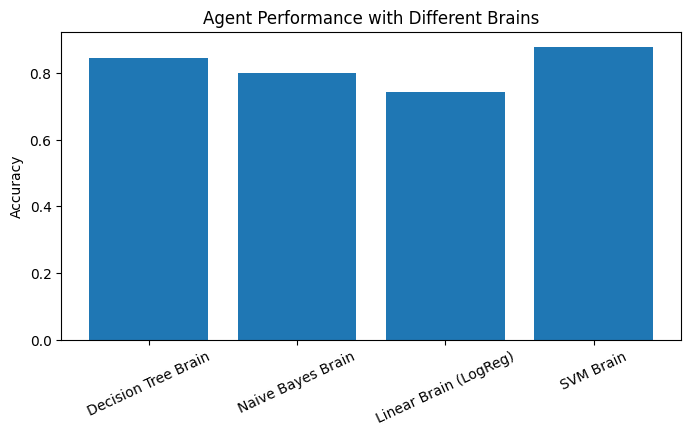

In [4]:
# ============================================================
# MULTI-BRAIN INTELLIGENT AGENT DEMO
# Decision Tree | Naive Bayes | Linear Model | SVM
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# ------------------------------------------------------------
# 1. ENVIRONMENT
# ------------------------------------------------------------
# Classification world
X, y = make_classification(
    n_samples=800,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ------------------------------------------------------------
# 2. BRAIN DEFINITIONS
# ------------------------------------------------------------
def create_brains():
    """
    Each brain has its own internal optimization mechanism
    """
    brains = {
        "Decision Tree Brain": DecisionTreeClassifier(
            max_depth=5
        ),
        "Naive Bayes Brain": GaussianNB(),
        "Linear Brain (LogReg)": LogisticRegression(
            solver="lbfgs", max_iter=1000
        ),
        "SVM Brain": SVC(
            kernel="rbf", C=1.0, gamma="scale"
        )
    }
    return brains

# ------------------------------------------------------------
# 3. AGENT DEFINITION
# ------------------------------------------------------------
class IntelligentAgent:
    """
    One agent, multiple brains
    """
    def __init__(self, brains):
        self.brains = brains
        self.performance = {}

    def perceive(self, X):
        """
        Perception = raw sensory input
        """
        return X

    def think_and_act(self, brain_name, X_train, y_train, X_test):
        """
        Thinking = internal brain training
        Acting = predicting labels
        """
        brain = self.brains[brain_name]

        # Brain optimization happens here
        brain.fit(X_train, y_train)

        predictions = brain.predict(X_test)
        return predictions

    def evaluate(self, predictions, y_true):
        """
        Reward signal
        """
        return accuracy_score(y_true, predictions)

    def live(self, X_train, y_train, X_test, y_test):
        """
        Agent tries each brain
        """
        sensory_data = self.perceive(X_train)

        for brain_name in self.brains:
            print(f"\n--- Activating {brain_name} ---")

            preds = self.think_and_act(
                brain_name,
                sensory_data,
                y_train,
                X_test
            )

            acc = self.evaluate(preds, y_test)
            self.performance[brain_name] = acc

            print(f"Accuracy: {acc:.4f}")

# ------------------------------------------------------------
# 4. RUN SIMULATION
# ------------------------------------------------------------
brains = create_brains()
agent = IntelligentAgent(brains)

agent.live(X_train, y_train, X_test, y_test)

# ------------------------------------------------------------
# 5. VISUAL COMPARISON
# ------------------------------------------------------------
plt.figure(figsize=(8,4))
plt.bar(agent.performance.keys(), agent.performance.values())
plt.xticks(rotation=25)
plt.ylabel("Accuracy")
plt.title("Agent Performance with Different Brains")
plt.show()
